Mean equation value: -2.1861475501005434
Std dev of equation values: 15.552433291236623


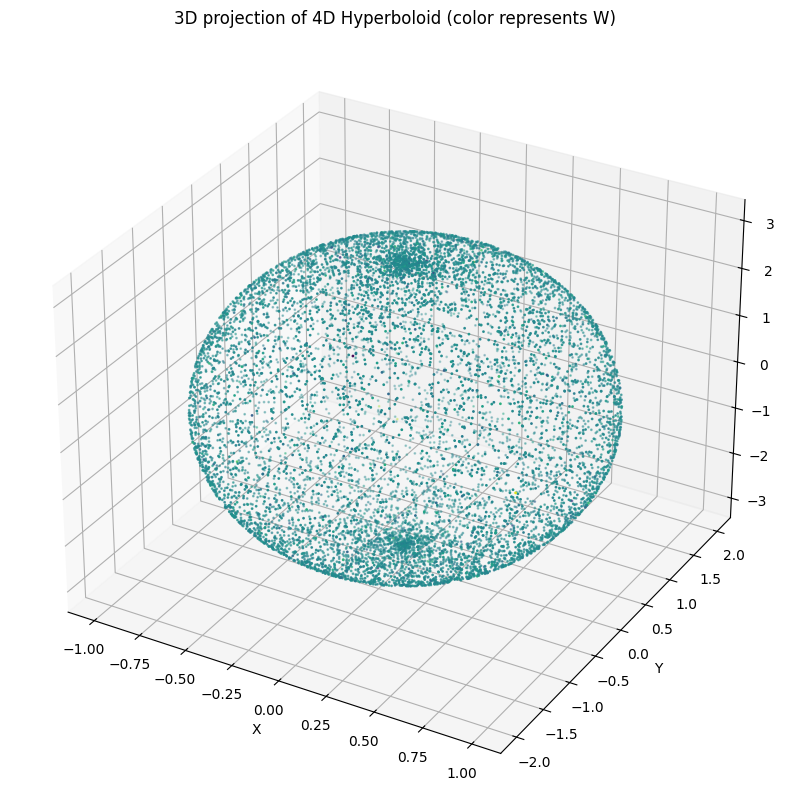

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sample_4d_hyperboloid(num_points, a, b, c, d):
    # Generate random values for theta, phi, and psi
    theta = np.random.uniform(-np.pi/2, np.pi/2, num_points)
    phi = np.random.uniform(0, 2*np.pi, num_points)
    psi = np.random.normal(0, 1, num_points)  # Using normal distribution for psi

    # Calculate the coordinates
    x = a * np.cos(theta) * np.cos(phi)
    y = b * np.cos(theta) * np.sin(phi)
    z = c * np.sin(theta)
    w = d * np.sinh(psi)

    return np.column_stack((x, y, z, w))

# Set the parameters
num_points = 10000
a, b, c, d = 1, 2, 3, 4

# Sample the points
points = sample_4d_hyperboloid(num_points, a, b, c, d)

# Verify that the points satisfy the hyperboloid equation (approximately)
equation_values = (points[:,0]**2 / a**2) + (points[:,1]**2 / b**2) + (points[:,2]**2 / c**2) - (points[:,3]**2 / d**2)
print(f"Mean equation value: {np.mean(equation_values)}")
print(f"Std dev of equation values: {np.std(equation_values)}")

# Visualize the first three dimensions
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:,0], points[:,1], points[:,2], c=points[:,3], cmap='viridis', s=1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('3D projection of 4D Hyperboloid (color represents W)')
plt.show()

In [6]:
import numpy as np
from scipy.spatial.distance import pdist, squareform

class StreamingRBFKernel:
    def __init__(self, points, gamma=1.0):
        self.points = points
        self.gamma = gamma
        self.n = len(points)
        
    def calculate_row(self, i):
        diff = self.points - self.points[i]
        sq_dists = np.sum(diff**2, axis=1)
        return np.exp(-self.gamma * sq_dists)
    
    def __getitem__(self, key):
        if isinstance(key, tuple):
            row_idx, col_idx = key
        else:
            row_idx, col_idx = key, slice(None)
        
        if isinstance(row_idx, int):
            row = self.calculate_row(row_idx)
            return row[col_idx]
        elif isinstance(row_idx, slice):
            start, stop, step = row_idx.indices(self.n)
            rows = np.array([self.calculate_row(i) for i in range(start, stop, step)])
            return rows[:, col_idx]
        elif isinstance(row_idx, (list, np.ndarray)):
            rows = np.array([self.calculate_row(i) for i in row_idx])
            return rows[:, col_idx]
        else:
            raise IndexError("Invalid index type")

    def __len__(self):
        return self.n

    @property
    def shape(self):
        return (self.n, self.n)

# Example usage:
# Use the previously sampled points
num_points = 11
a, b, c, d = 1, 2, 3, 4
points = sample_4d_hyperboloid(num_points, a, b, c, d)

# Create an instance of StreamingRBFKernel
kernel = StreamingRBFKernel(points, gamma=0.1)

# Examples of indexing
print("Shape of kernel:", (len(kernel), len(kernel)))

print("\nFirst row:")
print(kernel[0])

print("\nElement at (5, 10):")
print(kernel[5, 10])

print("\nSubmatrix [1:5, 2:6]:")
print(kernel[1:5, 2:6])

print("\nSpecific rows and columns:")
print(kernel[[1,3,5], [2,4,6]])

# Verify symmetry
# i, j = 10, 20
# print(f"\nSymmetry check: K[{i},{j}] == K[{j},{i}]")
# print(f"{kernel[i,j]} == {kernel[j,i]}")

# Compare with full kernel computation
print("\nComparing with full kernel computation:")
full_kernel = squareform(np.exp(-0.1 * pdist(points, 'sqeuclidean')))
print("Max difference:", np.max(np.abs(full_kernel - kernel[:, :])))

Shape of kernel: (11, 11)

First row:
[1.00000000e+00 5.20660868e-02 2.37688427e-01 2.45895128e-01
 5.79978907e-01 1.88939578e-13 8.30669854e-05 7.22466391e-02
 3.76922871e-03 1.10811841e-02 6.94851667e-04]

Element at (5, 10):
9.066852044517483e-06

Submatrix [1:5, 2:6]:
[[4.72937846e-01 6.38786668e-02 2.66082376e-01 8.19501005e-12]
 [1.00000000e+00 4.98169446e-01 7.84021021e-01 2.00191200e-14]
 [4.98169446e-01 1.00000000e+00 5.09446259e-01 5.82937776e-18]
 [7.84021021e-01 5.09446259e-01 1.00000000e+00 8.43445797e-14]]

Specific rows and columns:
[[4.72937846e-01 2.66082376e-01 1.42502642e-06]
 [4.98169446e-01 5.09446259e-01 9.85225440e-03]
 [2.00191200e-14 8.43445797e-14 2.06391180e-31]]

Comparing with full kernel computation:
Max difference: 1.0


In [9]:
import numpy as np

class StreamingKroneckerGraph:
    def __init__(self, SCALE, edgefactor):
        self.SCALE = SCALE
        self.N = 2**SCALE
        self.M = int(edgefactor * self.N)
        self.A, self.B, self.C = 0.57, 0.19, 0.19
        self.ab = self.A + self.B
        self.c_norm = self.C / (1 - (self.A + self.B))
        self.a_norm = self.A / (self.A + self.B)
        
        # Generate and store the edge list
        self.ijw = self._generate_edge_list()
        
    def _generate_edge_list(self):
        ijw = np.ones((3, self.M))
        for ib in range(1, self.SCALE + 1):
            ii_bit = np.random.uniform(0, 1, size=(1, self.M)) > self.ab
            jj_bit = np.random.uniform(0, 1, size=(1, self.M)) > (self.c_norm * ii_bit + self.a_norm * (~ii_bit))
            ijw[0:2] += 2**(ib - 1) * np.append(ii_bit, jj_bit, axis=0)
        
        ijw[2] = np.random.uniform(0, 1, size=(1, self.M))
        ijw[0] = np.random.permutation(ijw[0])
        ijw[1] = np.random.permutation(ijw[1])
        ijw[0:2] -= 1
        return ijw
    
    def _calculate_row(self, i):
        row = np.zeros(self.N)
        mask = (self.ijw[0] == i) | (self.ijw[1] == i)
        for j in range(self.M):
            if mask[j]:
                other_vertex = int(self.ijw[1][j] if self.ijw[0][j] == i else self.ijw[0][j])
                weight = self.ijw[2][j]
                if row[other_vertex] == 0 or weight < row[other_vertex]:
                    row[other_vertex] = weight
        return row
    
    def __getitem__(self, key):
        if isinstance(key, tuple):
            row_idx, col_idx = key
        else:
            row_idx, col_idx = key, slice(None)
        
        if isinstance(row_idx, int):
            row = self._calculate_row(row_idx)
            return row[col_idx]
        elif isinstance(row_idx, slice):
            start, stop, step = row_idx.indices(self.N)
            rows = np.array([self._calculate_row(i) for i in range(start, stop, step)])
            return rows[:, col_idx]
        elif isinstance(row_idx, (list, np.ndarray)):
            rows = np.array([self._calculate_row(i) for i in row_idx])
            return rows[:, col_idx]
        else:
            raise IndexError("Invalid index type")

    def __len__(self):
        return self.N

    @property
    def shape(self):
        return (self.N, self.N)

# Create an instance of StreamingRBFKernel
kernel = StreamingKroneckerGraph(5, edgefactor=0.5)
print("Shape of kernel:", (len(kernel), len(kernel)))

print("\nFirst row:")
print(kernel[0])

print("\nElement at (5, 10):")
print(kernel[5, 10])

print("\nSubmatrix [1:5, 2:6]:")
print(kernel[1:5, 2:6])

print("\nSpecific rows and columns:")
print(kernel[[1,3,5], [2,4,6]])

Shape of kernel: (32, 32)

First row:
[0.         0.14881536 0.68003824 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.45911548 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]

Element at (5, 10):
0.0

Submatrix [1:5, 2:6]:
[[0.         0.         0.1174946  0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.33982779 0.        ]
 [0.         0.33982779 0.         0.        ]]

Specific rows and columns:
[[0.         0.1174946  0.        ]
 [0.         0.33982779 0.        ]
 [0.         0.         0.        ]]


In [5]:
import numpy as np

# Parameters
n = 4  # Matrix size
lambda_vals = np.array([10, 5, 3, 1])  # Specified eigenvalues (spectrum)
f = np.array([[0.4, 0.3, 0.2, 0.1],  # Fraction of eigenpair in each row
              [0.3, 0.4, 0.2, 0.1],
              [0.2, 0.2, 0.4, 0.2],
              [0.1, 0.1, 0.2, 0.6]])

# Step 1: Create random orthogonal matrix V (for eigenvectors)
V, _ = np.linalg.qr(np.random.randn(n, n))  # Random orthogonal matrix for eigenvectors

# Step 2: Initialize the symmetric matrix A
A = np.zeros((n, n))

# Step 3: Construct matrix row by row
for j in range(n):  # For each row
    a_j = np.zeros(n)
    for i in range(n):  # For each eigenvalue/eigenvector pair
        c_ij = np.sqrt(f[j, i] * lambda_vals[i])  # Coefficient based on fraction and eigenvalue
        a_j += c_ij * V[:, i]  # Projection of row onto the eigenvector

    A[j, :] = a_j  # Assign the row

# # Step 4: Ensure symmetry by averaging A and A.T
# A = (A + A.T) / 2

# Step 5: Perform the SVD of matrix A
U, S, Vt = np.linalg.svd(A)

# The eigenvectors of A are in U, and the singular values in S are the square roots of the eigenvalues
# Since A is symmetric, U will be equivalent to V

# Step 6: Check projections of each row onto each eigenvector
projections = np.zeros((n, n))  # To store the projections for verification

for j in range(n):
    for i in range(n):
        # Compute the projection of row j onto eigenvector i
        projections[j, i] = np.dot(A[j, :], U[:, i])

# Step 7: Check if the sum of squared projections matches the desired fraction times the eigenvalue
verified_fractions = np.zeros((n, n))  # To store the verified fractions

for j in range(n):
    for i in range(n):
        # The squared norm of the projection should match f[j, i] * lambda_vals[i]
        verified_fractions[j, i] = (projections[j, i]**2) / lambda_vals[i]


In [7]:
verified_fractions, S

(array([[0.14417345, 0.8143306 , 0.11058153, 0.35486793],
        [0.13324243, 0.67042579, 0.23463637, 0.31153767],
        [0.19476007, 0.4133841 , 0.11197428, 0.04955597],
        [0.09963191, 0.28209094, 0.07469895, 0.06912936]]),
 array([4.29412523, 0.66551075, 0.26509173, 0.21750933]))

In [9]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(0)

# Define the problem parameters
n = 5  # Size of the matrix
spectrum = np.array([1, 2, 3, 4, 5])  # Specified eigenvalues
max_iterations = 1000
tolerance = 1e-8

# Initialize V as a random orthogonal matrix
V = np.linalg.qr(np.random.randn(n, n))[0]

# Create the diagonal matrix S with the specified spectrum
S = np.diag(spectrum)

for iteration in range(max_iterations):
    V_old = V.copy()
    
    for j in range(n):
        # Calculate desired squared values
        d = np.sum(V @ S * V, axis=1) * V[:, j] / spectrum[j]
        
        # Ensure non-negative values
        d = np.maximum(d, 0)
        
        # Normalize
        d_sum = np.sum(d)
        if d_sum > 0:
            d_hat = d / d_sum
        else:
            d_hat = np.ones(n) / n
        
        # Update jth column of V
        V[:, j] = np.sign(V[:, j]) * np.sqrt(d_hat)
    
    # Re-orthogonalize V
    V, _ = np.linalg.qr(V)
    
    # Check for convergence
    if np.allclose(V, V_old, atol=tolerance):
        break

# Construct the final matrix A
A = V @ S @ V.T

# Ensure symmetry (to avoid numerical errors)
A = (A + A.T) / 2

# Check condition 1: Specified spectrum
eigenvalues, eigenvectors = np.linalg.eigh(A)
print("Condition 1 check:")
print("Specified spectrum:", spectrum)
print("Actual eigenvalues:", eigenvalues)
print("Condition 1 satisfied:", np.allclose(np.sort(eigenvalues), np.sort(spectrum), atol=1e-6))

# Check condition 2: Row projections
print("\nCondition 2 check:")
for j in range(n):
    eigenvector = eigenvectors[:, j]
    projections_sum = np.sum(np.abs(A @ eigenvector * eigenvector))
    print(f"Eigenvalue {j+1}: {eigenvalues[j]:.4f}, Sum of projections: {projections_sum:.4f}")
print("Condition 2 satisfied:", np.allclose(np.sum(np.abs(A @ eigenvectors * eigenvectors), axis=0), eigenvalues, atol=1e-6))

print("\nResulting matrix A:")
print(A)

Condition 1 check:
Specified spectrum: [1 2 3 4 5]
Actual eigenvalues: [1. 2. 3. 4. 5.]
Condition 1 satisfied: True

Condition 2 check:
Eigenvalue 1: 1.0000, Sum of projections: 1.0000
Eigenvalue 2: 2.0000, Sum of projections: 2.0000
Eigenvalue 3: 3.0000, Sum of projections: 3.0000
Eigenvalue 4: 4.0000, Sum of projections: 4.0000
Eigenvalue 5: 5.0000, Sum of projections: 5.0000
Condition 2 satisfied: True

Resulting matrix A:
[[ 2.76948038  0.29780894  0.          0.         -0.29780894]
 [ 0.29780894  1.61525981  0.          0.         -0.61525981]
 [ 0.          0.          5.          0.          0.        ]
 [ 0.          0.          0.          4.          0.        ]
 [-0.29780894 -0.61525981  0.          0.          1.61525981]]


In [1]:
import numpy as np
import scipy as sp

def construct_symmetric_matrix(eigenvalues, f, max_iterations=1000, tolerance=1e-6):
    n = len(eigenvalues)
    S = np.diag(eigenvalues)
    
    # Initialize V with square root of f and random signs
    V = np.sqrt(f) * np.sign(np.random.randn(n, n))
    
    for _ in range(max_iterations):
        V_old = V.copy()
        
        # Modified Gram-Schmidt process
        for j in range(n):
            # Normalize the column
            V[:, j] = V[:, j] / np.linalg.norm(V[:, j])
            
            # Orthogonalize with respect to previous columns
            for k in range(j+1, n):
                V[:, k] = V[:, k] - np.dot(V[:, j], V[:, k]) * V[:, j]
            
            # Re-apply the signs and magnitudes
            V[:, j] = np.sign(V[:, j]) * np.sqrt(f[:, j])
        
        # Check for convergence
        if np.allclose(V, V_old, atol=tolerance):
            break
    
    # Construct the symmetric matrix
    V = sp.linalg.orth(V)
    A = V @ S @ V.T
    
    return A, V

def gram_schmidt(A):
    """
    Applies the Gram-Schmidt process to the columns of A.
    Returns Q (orthonormalized A) and R (upper triangular matrix).
    """
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    
    for j in range(n):
        v = A[:, j]
        for i in range(j):
            R[i, j] = np.dot(Q[:, i], A[:, j])
            v = v - R[i, j] * Q[:, i]
        R[j, j] = np.linalg.norm(v)
        Q[:, j] = v / R[j, j] if R[j, j] != 0 else v
    
    return Q, R

# raise
# f = np.array([
#     [0.9, 0.0, 0.0, 0.1],
#     [0.0, 0.9, 0.0, 0.1],
#     [0.0, 0.0, 0.9, 0.1],
#     [0.1, 0.1, 0.1, 0.7]
# ])
# f = np.array([
#     [0.9, 0.0, 0.0, 0.0, 0.1],
#     [0.0, 0.9, 0.0, 0.0, 0.1],
#     [0.0, 0.0, 0.9, 0.0, 0.1],
#     [0.0, 0.0, 0.0, 0.9, 0.1],
#     [0.1, 0.1, 0.1, 0.1, 0.6],
# ])
# f = f 


# Example usage

n = 5
first_ev = 1
last_ev = 10
last_elem = 0.01
eigenvalues = np.linspace(first_ev, last_ev, n)#np.array([1, 2, 5, 7, 10])
print(last_ev * (1-last_elem) / (n-1) - first_ev, last_ev * last_elem - first_ev)

# Create the matrix
f = np.zeros((n, n))
# last_elem = 0.6

# Set the diagonal elements to 0.9
np.fill_diagonal(f, 1 - (1-last_elem) / (n-1))
f[-1,-1] = last_elem

# Set the last column to 0.1, except for the last element
f[:n-1, -1] = (1-last_elem) / (n-1)

# Set the last row to 0.1, except for the last element
f[-1, :n-1] = (1-last_elem) / (n-1)

V = np.sqrt(f) + 0.2*np.random.rand(n,n)
# print(V)
# V, _ = np.linalg.qr(V)
V, _ = gram_schmidt(V)
print(V[-1,-1])
# print(V)

# # print(f)
# print("\nRow sums:", f.sum(axis=1))
# print("Column sums:", f.sum(axis=0))
# f = sp.linalg.orth(f)
# print(f)
# V = np.linalg.cholesky(f)
# V = np.sqrt(f)
# V, R = np.linalg.qr(V)
# print(V[-1,-1])
A = V @ np.diag(eigenvalues) @ V.T

# A, V = construct_symmetric_matrix(eigenvalues, f)
evals, evecs = np.linalg.eigh(A)

# Verify the results
# print("Resulting symmetric matrix A:")
# print(A)
# print("\nEigenvalues of A:")
# print(evals)
# print("\nFraction of eigenpairs in each row:")
# print(evecs)
# print("\nDesired:")
# print(f)
# print(evecs * evals.reshape(1,-1))

# Verification using projections
# print("\nVerification using projections:")
# for j in range(n):
#     eigenvector = V[:, j]
#     eigenvalue = eigenvalues[j]
    
#     projections = np.array([
#         np.dot(A[i], eigenvector)**2 / (np.dot(eigenvector, eigenvector) * eigenvalue)
#         for i in range(n)
#     ])
#     projections *= 1 / eigenvalue
    
#     print(f"\nFraction of eigenpair {j+1} in each row (from projections):")
#     print(projections)
#     print("Sum of fractions:", np.sum(projections))
#     print("Difference from V^2:", np.abs(projections - np.square(V[:, j])))

# # Check orthogonality of V
# print("\nCheck orthogonality of V:")
# print("V^T * V:")
# print(V.T @ V)

1.475 -0.9
-0.7226211364836028


In [133]:
V**2

array([[6.80866240e-01, 3.13742760e-02, 8.97054356e-02, 3.67918736e-02,
        1.61262175e-01],
       [3.57915533e-05, 8.98657883e-01, 5.82496139e-02, 2.76103265e-03,
        4.02956788e-02],
       [7.08521277e-03, 1.44175194e-02, 7.50508360e-01, 6.27914639e-02,
        1.65197444e-01],
       [8.58692650e-03, 4.17015890e-05, 1.05770871e-02, 8.68967985e-01,
        1.11826300e-01],
       [3.03425829e-01, 5.55086200e-02, 9.09595039e-02, 2.86876450e-02,
        5.21418402e-01]])

In [3]:
import numpy as np

def generate_equiangular_matrix(n, C):
    """
    Generate a matrix with n rows where the inner product between any two rows is C.
    
    :param n: Number of rows in the matrix
    :param C: Desired inner product between any two rows
    :return: numpy array of shape (n, n)
    """
    if n < 2:
        raise ValueError("n must be at least 2")
    if C < -1/(n-1) or C > 1:
        raise ValueError(f"C must be between {-1/(n-1)} and 1 inclusive")
    
    # Calculate the diagonal elements
    a = np.sqrt((1 - C) / (1 + C*(n-1)))
    
    # Create the matrix
    matrix = np.full((n, n), C)
    np.fill_diagonal(matrix, a)
    
    return matrix

# Example usage
n = 5
C = 0.5
matrix = generate_equiangular_matrix(n, C)

# Verify the result
for i in range(n):
    for j in range(i+1, n):
        print(f"Inner product of row {i} and row {j}: {np.dot(matrix[i], matrix[j]):.6f}")

Inner product of row 0 and row 1: 1.158248
Inner product of row 0 and row 2: 1.158248
Inner product of row 0 and row 3: 1.158248
Inner product of row 0 and row 4: 1.158248
Inner product of row 1 and row 2: 1.158248
Inner product of row 1 and row 3: 1.158248
Inner product of row 1 and row 4: 1.158248
Inner product of row 2 and row 3: 1.158248
Inner product of row 2 and row 4: 1.158248
Inner product of row 3 and row 4: 1.158248


In [21]:
import numpy as np

n = 4
C = 0.01

# Generate Gram matrix
G = np.full((n, n), C)
np.fill_diagonal(G, 1)

print("Gram matrix G:")
print(G)

# Calculate eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(G)

# Construct target matrix A
A = eigenvectors @ np.diag(np.sqrt(np.maximum(eigenvalues, 0)))

print("\nTarget matrix A:")
print(A)

# Verify the properties
print("\nVerifying properties:")
print("1. A * A^T ≈ G:")
print(np.allclose(A @ A.T, G))

print("\n2. Row lengths:")
print(np.linalg.norm(A, axis=1))

print("\n3. Inner products between rows:")
print(A @ A.T)

Gram matrix G:
[[1.   0.01 0.01 0.01]
 [0.01 1.   0.01 0.01]
 [0.01 0.01 1.   0.01]
 [0.01 0.01 0.01 1.  ]]

Target matrix A:
[[ 0.00000000e+00  0.00000000e+00 -8.61684397e-01 -5.07444578e-01]
 [ 8.12403840e-01 -8.71216267e-17  2.87228132e-01 -5.07444578e-01]
 [-4.06201920e-01 -7.03562364e-01  2.87228132e-01 -5.07444578e-01]
 [-4.06201920e-01  7.03562364e-01  2.87228132e-01 -5.07444578e-01]]

Verifying properties:
1. A * A^T ≈ G:
True

2. Row lengths:
[1. 1. 1. 1.]

3. Inner products between rows:
[[1.   0.01 0.01 0.01]
 [0.01 1.   0.01 0.01]
 [0.01 0.01 1.   0.01]
 [0.01 0.01 0.01 1.  ]]


In [22]:
import numpy as np

def make_diagonally_dominant(A, max_iterations=1000, tolerance=1e-6):
   n = A.shape[0]
   for _ in range(max_iterations):
       improved = False
       for i in range(n):
           for j in range(i+1, n):
               # Compute Givens rotation parameters
               a, b = A[i,i], A[i,j]
               if abs(b) > tolerance:
                   tau = (b-a) / (b+a)
                   t = np.sign(tau) / (abs(tau) + np.sqrt(1 + tau**2))
                   c = 1 / np.sqrt(1 + t**2)
                   s = t * c

                   # Apply Givens rotation
                   G = np.eye(n)
                   G[i,i] = G[j,j] = c
                   G[i,j] = s
                   G[j,i] = -s
                   A = A @ G

                   improved = True

       # Check if diagonally dominant
       if np.all(2 * np.abs(np.diag(A)) >= np.sum(np.abs(A), axis=1)):
           break

       if not improved:
           break

   return A

# Example usage
# n = 4
# C = 0.3
# G = np.full((n, n), C)
# np.fill_diagonal(G, 1)
# A = np.linalg.cholesky(G)

A_rotated = make_diagonally_dominant(A)
print("Original A:")
print(A)
print("\nRotated A:")
print(A_rotated)
print("\nIs diagonally dominant:", np.all(2 * np.abs(np.diag(A_rotated)) >= np.sum(np.abs(A_rotated), axis=1)))
print("\nGram matrix of rotated A:")
print(A_rotated @ A_rotated.T)

Original A:
[[ 0.00000000e+00  0.00000000e+00 -8.61684397e-01 -5.07444578e-01]
 [ 8.12403840e-01 -8.71216267e-17  2.87228132e-01 -5.07444578e-01]
 [-4.06201920e-01 -7.03562364e-01  2.87228132e-01 -5.07444578e-01]
 [-4.06201920e-01  7.03562364e-01  2.87228132e-01 -5.07444578e-01]]

Rotated A:
[[-0.50040187  0.50036576  0.49412399  0.50504807]
 [ 0.48295913 -0.50607914  0.50140825  0.5091406 ]
 [-0.38377016 -0.37685824 -0.59609601  0.5961274 ]
 [ 0.59954216  0.58471582 -0.37297131  0.39943586]]

Is diagonally dominant: False

Gram matrix of rotated A:
[[1.   0.01 0.01 0.01]
 [0.01 1.   0.01 0.01]
 [0.01 0.01 1.   0.01]
 [0.01 0.01 0.01 1.  ]]


In [20]:
A**2

array([[0.00000000e+00, 0.00000000e+00, 7.42500000e-01, 2.57500000e-01],
       [6.60000000e-01, 7.59017783e-33, 8.25000000e-02, 2.57500000e-01],
       [1.65000000e-01, 4.95000000e-01, 8.25000000e-02, 2.57500000e-01],
       [1.65000000e-01, 4.95000000e-01, 8.25000000e-02, 2.57500000e-01]])

In [11]:
np.linalg.eigh(G)

(array([0.99, 0.99, 1.02]), array([[-0.53926555, -0.61307368,  0.57735027],
        [ 0.80057015, -0.16048083,  0.57735027],
        [-0.26130461,  0.7735545 ,  0.57735027]]))

In [131]:
np.abs(V[0,-1] * last_ev), np.abs(V[0,0] * first_ev)

(4.015746192075914, 0.8251461931769639)

In [132]:
np.abs(V[-1,-1] * last_ev), np.abs(V[0,0] * first_ev)

(7.22093070154111, 0.8251461931769639)

In [ ]:
last_ev * (1-last_elem) / (n-1) < first_ev, last_ev * last_elem < first_ev

In [52]:
(V**2).sum(0)

array([1., 1., 1., 1., 1.])

In [28]:
import math

# Given: C^2 = -xy and x^2 + y^2 = 1 - C^2

# Let's try different values of C
C = 0.05

print(f"\nCalculations for C = {C:.4f}:")

# Calculate x
x_squared = ((1 - C**2) + math.sqrt(1 - 2*C**2 - 3*C**4)) / 2
x = math.sqrt(x_squared)

# Calculate y
y = -C**2 / x

print(f"x = {x:.4f}")
print(f"y = {y:.4f}")

# Verify x^2 + y^2 = 1 - C^2
lhs = x**2 + y**2
rhs = 1 - C**2
print(f"x^2 + y^2 = {lhs:.4f}, 1 - C^2 = {rhs:.4f}")

# Verify xy = -C^2
print(f"xy = {x*y:.4f}, -C^2 = {-C**2:.4f}")

# Calculate vectors a and b
a = (x, y, 0)
b = (0, x, y)

# Calculate magnitudes
mag_a = math.sqrt(sum([i**2 for i in a]))
mag_b = math.sqrt(sum([i**2 for i in b]))
print(f"|a| = {mag_a:.4f}, |b| = {mag_b:.4f}")

# Calculate dot product
dot_product = sum([a[i]*b[i] for i in range(3)])
print(f"a · b = {dot_product:.4f}")

# Calculate cos(θ)
cos_theta = dot_product / (mag_a * mag_b)
print(f"cos(θ) = {cos_theta:.4f}")

# Calculate θ in degrees
theta = math.degrees(math.acos(cos_theta))
print(f"θ = {theta:.2f} degrees")


Calculations for C = 0.0500:
x = 0.9987
y = -0.0025
x^2 + y^2 = 0.9975, 1 - C^2 = 0.9975
xy = -0.0025, -C^2 = -0.0025
|a| = 0.9987, |b| = 0.9987
a · b = -0.0025
cos(θ) = -0.0025
θ = 90.14 degrees


In [47]:
import numpy as np

def transform_hadamard(n, alpha):
    # Create Hadamard matrix
    H = np.array([[1]])
    for i in range(int(np.log2(n))):
        H = np.block([[H, H], [H, -H]])
    
    # Normalize
    H = H / np.sqrt(n)
    
    # Transform
    new_H = H.copy()
#     new_H[:-1,:-1] *= alpha
#     np.fill_diagonal(new_H[:-1,:-1], np.sqrt(1 - (n-2)*alpha**2/n))
    
    return new_H

# Example usage
n = 4
alpha = 0.3
U = transform_hadamard(n, alpha)
print(U)
print("Is unitary:", np.allclose(np.eye(n), U @ U.conj().T))
print("Last column:", U[:,-1])

[[ 0.5  0.5  0.5  0.5]
 [ 0.5 -0.5  0.5 -0.5]
 [ 0.5  0.5 -0.5 -0.5]
 [ 0.5 -0.5 -0.5  0.5]]
Is unitary: True
Last column: [ 0.5 -0.5 -0.5  0.5]


In [91]:
import numpy as np

def generate_unitary_matrix(n):
    # Start with a Hadamard matrix
    H = hadamard_matrix(n)
    
    # Initialize the new unitary matrix
    U = np.zeros((n, n), dtype=complex)
    
    # Set the first column
    U[:, 0] = 1 / np.sqrt(n)
    
    # Generate the remaining columns
    for j in range(1, n):
        # Start with a vector that has 1 on the diagonal and small random values elsewhere
        v = np.random.random(n) * 0.1
        v[j-1] = 1
#         if j < n:
        v[j] = -1
        
        # Orthogonalize against previous columns
#         print(v)
        for i in range(j):
            v = v - np.dot(np.conj(U[:, i]), v) * U[:, i]
#             print(v)
        
        # Normalize
        U[:, j] = v / np.linalg.norm(v)
    
    return U

def hadamard_matrix(n):
    # Check if n is a power of 2
    if n & (n - 1) != 0:
        raise ValueError("n must be a power of 2")
    
    # Base case: 1x1 Hadamard matrix
    if n == 1:
        return np.array([[1]])
    
    # Recursive case
    H = hadamard_matrix(n // 2)
    return np.block([[H, H], [H, -H]]) / np.sqrt(2)

# Generate a 8x8 unitary matrix
n = 8
U = generate_unitary_matrix(n)

# Print the matrix
np.set_printoptions(precision=3, suppress=True)
print("Generated Unitary Matrix:")
print(U)

# Verify unitarity
UU_dag = np.dot(U, U.conj().T)
print("\nU * U^dag (should be close to the identity matrix):")
print(UU_dag)

# Check orthogonality of columns
print("\nDot products between columns (should be close to 0 for i != j and 1 for i == j):")
for i in range(n):
    for j in range(i, n):
        dot_product = np.dot(np.conj(U[:, i]), U[:, j])
        print(f"Columns {i+1} and {j+1}: {dot_product:.3f}")

# Check diagonal dominance for columns 2 to n
print("\nChecking diagonal dominance for columns 2 to n:")
for j in range(1, n):
    diagonal = abs(U[j, j])
    off_diagonal_sum = sum(abs(U[i, j]) for i in range(n) if i != j)
    print(f"Column {j+1}: |U[{j+1},{j+1}]| = {diagonal:.3f}, sum of off-diagonal = {off_diagonal_sum:.3f}")

Generated Unitary Matrix:
[[ 0.354+0.j  0.673+0.j  0.406+0.j  0.27 +0.j  0.149+0.j  0.256+0.j
   0.189+0.j  0.246+0.j]
 [ 0.354+0.j -0.737+0.j  0.347+0.j  0.261+0.j  0.187+0.j  0.201+0.j
   0.174+0.j  0.192+0.j]
 [ 0.354+0.j  0.026+0.j -0.841+0.j  0.25 +0.j  0.193+0.j  0.158+0.j
   0.155+0.j  0.135+0.j]
 [ 0.354+0.j  0.001+0.j -0.001+0.j -0.887+0.j  0.202+0.j  0.112+0.j
   0.153+0.j  0.109+0.j]
 [ 0.354+0.j -0.031+0.j -0.032+0.j -0.035+0.j -0.923+0.j  0.084+0.j
   0.077+0.j  0.079+0.j]
 [ 0.354+0.j  0.031+0.j  0.047+0.j  0.069+0.j  0.063+0.j -0.918+0.j
   0.106+0.j  0.091+0.j]
 [ 0.354+0.j  0.006+0.j  0.014+0.j  0.009+0.j  0.066+0.j  0.042+0.j
  -0.929+0.j  0.071+0.j]
 [ 0.354+0.j  0.031+0.j  0.06 +0.j  0.062+0.j  0.063+0.j  0.066+0.j
   0.073+0.j -0.923+0.j]]

U * U^dag (should be close to the identity matrix):
[[ 1.+0.j  0.+0.j  0.+0.j -0.+0.j -0.+0.j -0.+0.j -0.+0.j -0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j -0.+0.j -0.+0.j  0.+0.j -0.+0.j -0.+0.j]
 [ 0.+0.j  0.+0.j  1.+0.j -0.+0.j -0.+0.j 

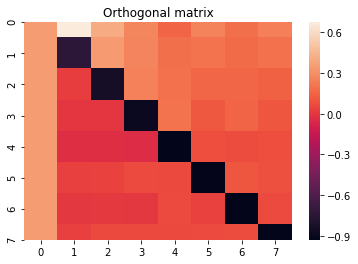

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.heatmap(U.real)
plt.title("Orthogonal matrix")
plt.show()

In [87]:
import numpy as np

class StreamingUnitaryMatrix:
    def __init__(self, n):
        if n & (n - 1) != 0:
            raise ValueError("n must be a power of 2")
        self.n = n
        self.U = None
        
    def generate_matrix(self):
        # Start with a Hadamard matrix
        H = self.hadamard_matrix(self.n)
        
        # Initialize the new unitary matrix
        self.U = np.zeros((self.n, self.n), dtype=complex)
        
        # Set the first column
        self.U[:, 0] = 1 / np.sqrt(self.n)
        
        # Generate the remaining columns
        for j in range(1, self.n):
            # Start with a vector that has 1 on the diagonal and small random values elsewhere
            v = np.random.random(self.n) * 0.1
            v[j-1] = 1
            v[j] = -1
            
            # Orthogonalize against previous columns
            for i in range(j):
                v = v - np.dot(np.conj(self.U[:, i]), v) * self.U[:, i]
            
            # Normalize
            self.U[:, j] = v / np.linalg.norm(v)
    
    def hadamard_matrix(self, n):
        # Base case: 1x1 Hadamard matrix
        if n == 1:
            return np.array([[1]])
        
        # Recursive case
        H = self.hadamard_matrix(n // 2)
        return np.block([[H, H], [H, -H]]) / np.sqrt(2)
    
    def __getitem__(self, key):
        if self.U is None:
            self.generate_matrix()
        
        if isinstance(key, tuple):
            row_idx, col_idx = key
        else:
            row_idx, col_idx = key, slice(None)
        
        return self.U[row_idx, col_idx]
    
    def __len__(self):
        return self.n
    
    @property
    def shape(self):
        return (self.n, self.n)

In [44]:
A = np.eye(3)
np.fill_diagonal(A, x)
np.fill_diagonal(A[:, 1:], y)
A = np.concatenate([A, np.repeat(C, 3).reshape(-1,1)], axis=1)
A

array([[ 0.99874608, -0.00250314,  0.        ,  0.05      ],
       [ 0.        ,  0.99874608, -0.00250314,  0.05      ],
       [ 0.        ,  0.        ,  0.99874608,  0.05      ]])

In [65]:
Q, R

(array([[-0.9486833 ,  0.09534626,  0.08703883,  0.08006408, -0.2773501 ],
        [-0.        , -0.95346259,  0.08703883,  0.08006408, -0.2773501 ],
        [-0.        ,  0.        , -0.95742711,  0.08006408, -0.2773501 ],
        [-0.        ,  0.        ,  0.        , -0.96076892, -0.2773501 ],
        [-0.31622777, -0.28603878, -0.26111648, -0.24019223,  0.83205029]]),
 array([[-1.        , -0.1       , -0.1       , -0.1       , -0.54494897],
        [ 0.        , -0.99498744, -0.0904534 , -0.0904534 , -0.49292489],
        [ 0.        ,  0.        , -0.99086739, -0.08257228, -0.44997681],
        [ 0.        ,  0.        ,  0.        , -0.98742088, -0.41391846],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.29368018]]))

In [66]:
-Q, -R

(array([[ 0.9486833 , -0.09534626, -0.08703883, -0.08006408,  0.2773501 ],
        [ 0.        ,  0.95346259, -0.08703883, -0.08006408,  0.2773501 ],
        [ 0.        , -0.        ,  0.95742711, -0.08006408,  0.2773501 ],
        [ 0.        , -0.        , -0.        ,  0.96076892,  0.2773501 ],
        [ 0.31622777,  0.28603878,  0.26111648,  0.24019223, -0.83205029]]),
 array([[ 1.        ,  0.1       ,  0.1       ,  0.1       ,  0.54494897],
        [-0.        ,  0.99498744,  0.0904534 ,  0.0904534 ,  0.49292489],
        [-0.        , -0.        ,  0.99086739,  0.08257228,  0.44997681],
        [-0.        , -0.        , -0.        ,  0.98742088,  0.41391846],
        [-0.        , -0.        , -0.        , -0.        , -0.29368018]]))